# Model Comparison: SolarGRU vs SolarGNN

This notebook trains both models on the same data split and compares:
- Quantitative metrics (MAE, RMSE, Skill Score, R²) per forecast horizon
- Prediction time series vs actual
- Scatter plots (predicted vs actual kt)
- Error distributions
- Clear day vs cloudy day case studies

**Target:** Spain station (41.93°N, -4.26°W)
**Horizons:** 1h, 6h, 24h
**Baseline:** Naive persistence

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from pathlib import Path

from src.loader      import load_all
from src.features    import engineer, MultiSiteScaler, TARGET_FEAT_COLS, NEIGHBOR_FEAT_COLS
from src.dataset     import SolarDataset
from src.dataset_gnn import GraphSolarDataset, GNN_FEAT_COLS
from src.graph       import build_graph
from src.model       import SolarGRU
from src.model_gnn   import SolarGNN
from src.train       import masked_mse_loss
from src.metrics     import mae, rmse, nrmse, skill_score, r2

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
torch.manual_seed(42); np.random.seed(42)

DATA_DIR  = '../data'
TARGET_ID = '41.93'
HORIZONS  = [1, 6, 24]
H_LABELS  = ['1h', '6h', '24h']
LOOKBACK  = 24
EPOCHS    = 80
PATIENCE  = 12
DEVICE    = 'cpu'
print('Setup complete')

Setup complete


## 1. Shared data pipeline

In [2]:
target_raw, neighbor_raws = load_all(DATA_DIR, TARGET_ID)
target_feat    = engineer(target_raw)
neighbor_feats = [engineer(df) for df in neighbor_raws]

T         = len(target_feat)
train_end = int(T * 0.70)
val_end   = int(T * 0.85)
print(f'T={T}  train={train_end}  val={val_end-train_end}  test={T-val_end}')

kt_raw       = target_feat['kt'].values
clearsky_raw = target_raw['Clearsky GHI'].values
timestamps   = target_feat.index

def persistence(kt, horizons):
    out = []
    for h in horizons:
        col = np.zeros(len(kt))
        col[h:] = kt[:-h]
        out.append(col)
    return np.stack(out, axis=1)

pers_all = persistence(kt_raw, HORIZONS)
max_h    = max(HORIZONS)

def get_subset(ds, lo, hi):
    lo = max(lo, LOOKBACK); hi = min(hi, T - max_h - 1)
    return Subset(ds, list(range(max(0, lo-LOOKBACK), min(len(ds), hi-LOOKBACK+1))))

print('Data loaded and shared pipeline ready')

[loader] Target   : 231955_41.93_-4.26_tdy-2022.csv  (8760 rows)
[loader] Neighbor : 231954_45_-40.26_tdy-2022.csv  (8760 rows)
T=8760  train=6132  val=1314  test=1314
Data loaded and shared pipeline ready


## 2. Build and train SolarGRU

In [3]:
sc_gru = MultiSiteScaler()
sc_gru.fit_transform_target(target_feat.iloc[:train_end], TARGET_FEAT_COLS)
t_sc   = sc_gru.transform_target(target_feat, TARGET_FEAT_COLS)
n_sc   = []
for i, nf in enumerate(neighbor_feats):
    sc_gru.fit_transform_neighbor(nf.iloc[:train_end], NEIGHBOR_FEAT_COLS, i)
    n_sc.append(sc_gru.transform_neighbor(nf, NEIGHBOR_FEAT_COLS, i))

full_gru = SolarDataset(
    t_sc[TARGET_FEAT_COLS].values,
    [df[NEIGHBOR_FEAT_COLS].values for df in n_sc],
    kt_raw, clearsky_raw, lookback=LOOKBACK, horizons=HORIZONS
)
gru_train = get_subset(full_gru, 0, train_end)
gru_val   = get_subset(full_gru, train_end, val_end)
gru_test  = get_subset(full_gru, val_end, T)
print(f'GRU — train:{len(gru_train)} val:{len(gru_val)} test:{len(gru_test)}')

GRU — train:6109 val:1315 test:1290


In [4]:
def train_loop(model, train_loader, val_loader, fwd, epochs=80, patience=12):
    model = model.to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)
    best_val, best_state, no_imp = float('inf'), None, 0
    hist  = {'train': [], 'val': []}
    for ep in range(1, epochs+1):
        model.train()
        tl = []
        for batch in train_loader:
            *inp, y, isd = [b.to(DEVICE) for b in batch]
            opt.zero_grad()
            loss = masked_mse_loss(fwd(model, inp), y, isd)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tl.append(loss.item())
        model.eval()
        vl = []
        with torch.no_grad():
            for batch in val_loader:
                *inp, y, isd = [b.to(DEVICE) for b in batch]
                vl.append(masked_mse_loss(fwd(model, inp), y, isd).item())
        tl, vl = np.mean(tl), np.mean(vl)
        hist['train'].append(tl); hist['val'].append(vl)
        sched.step(vl)
        if vl < best_val - 1e-5:
            best_val = vl
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f'  Early stop ep {ep}'); break
        if ep % 20 == 0 or ep == 1:
            print(f'  ep {ep:>3} | train {tl:.5f} | val {vl:.5f}')
    model.load_state_dict(best_state)
    return model, hist

def run_predict(model, loader, fwd):
    model.eval()
    yt, yp, yd = [], [], []
    with torch.no_grad():
        for batch in loader:
            *inp, y, isd = batch
            pred = fwd(model, [i.to(DEVICE) for i in inp])
            yt.append(y.numpy()); yp.append(pred.cpu().numpy()); yd.append(isd.numpy())
    return np.concatenate(yt), np.concatenate(yp), np.concatenate(yd)

n_t = len(TARGET_FEAT_COLS)
n_n = len(neighbor_feats) * len(NEIGHBOR_FEAT_COLS)
gru_model = SolarGRU(n_t, n_n, 64, 32, 2, len(HORIZONS), 0.2)
print(f'GRU params: {sum(p.numel() for p in gru_model.parameters()):,}')
print('Training GRU...')
gru_fwd = lambda m, inp: m(inp[0], inp[1])
gru_model, gru_hist = train_loop(
    gru_model,
    DataLoader(gru_train, 64, shuffle=True),
    DataLoader(gru_val,   64, shuffle=False),
    gru_fwd
)
gru_true, gru_pred, gru_day = run_predict(gru_model, DataLoader(gru_test, 64), gru_fwd)
print('GRU training complete')

GRU params: 49,155
Training GRU...


  ep   1 | train 0.11539 | val 0.09620


  ep  20 | train 0.05387 | val 0.09173


  Early stop ep 29
GRU training complete


## 3. Build and train SolarGNN

In [5]:
all_paths      = sorted(Path(DATA_DIR).glob('*.csv'))
target_path    = next(p for p in all_paths if TARGET_ID in p.name)
neighbor_paths = [p for p in all_paths if TARGET_ID not in p.name]
coords, adj_norm = build_graph(target_path, neighbor_paths, sigma_km=500.0)
adj_norm = adj_norm.to(DEVICE)

sc_gnn = MultiSiteScaler()
all_eng = [target_feat] + neighbor_feats
sc_gnn.fit_transform_target(all_eng[0].iloc[:train_end], GNN_FEAT_COLS)
gnn_t = sc_gnn.transform_target(all_eng[0], GNN_FEAT_COLS)
gnn_ns = []
for i, df in enumerate(all_eng[1:]):
    sc_gnn.fit_transform_neighbor(df.iloc[:train_end], GNN_FEAT_COLS, i)
    gnn_ns.append(sc_gnn.transform_neighbor(df, GNN_FEAT_COLS, i))

station_arrs = [gnn_t[GNN_FEAT_COLS].values] + [df[GNN_FEAT_COLS].values for df in gnn_ns]
full_gnn = GraphSolarDataset(station_arrs, kt_raw, clearsky_raw, lookback=LOOKBACK, horizons=HORIZONS)
gnn_train = get_subset(full_gnn, 0, train_end)
gnn_val   = get_subset(full_gnn, train_end, val_end)
gnn_test  = get_subset(full_gnn, val_end, T)
print(f'GNN — train:{len(gnn_train)} val:{len(gnn_val)} test:{len(gnn_test)}')

[graph] 2 station(s)
  node 0 (target)  lat=41.93 lon=-4.26  →node1: 0.000
  node 1 (neighbour 1)  lat=45.93 lon=-40.26  →node0: 0.000
GNN — train:6109 val:1315 test:1290


In [6]:
gnn_model = SolarGNN(len(GNN_FEAT_COLS), 32, 64, 2, len(HORIZONS), 0.2)
print(f'GNN params: {sum(p.numel() for p in gnn_model.parameters()):,}')
print('Training GNN...')
gnn_fwd = lambda m, inp: m(inp[0], adj_norm)
gnn_model, gnn_hist = train_loop(
    gnn_model,
    DataLoader(gnn_train, 64, shuffle=True),
    DataLoader(gnn_val,   64, shuffle=False),
    gnn_fwd
)
gnn_true, gnn_pred, gnn_day = run_predict(gnn_model, DataLoader(gnn_test, 64), gnn_fwd)
print('GNN training complete')

GNN params: 47,619
Training GNN...


  ep   1 | train 0.13887 | val 0.10959


  ep  20 | train 0.06311 | val 0.09530


  Early stop ep 31
GNN training complete


## 4. Training curves

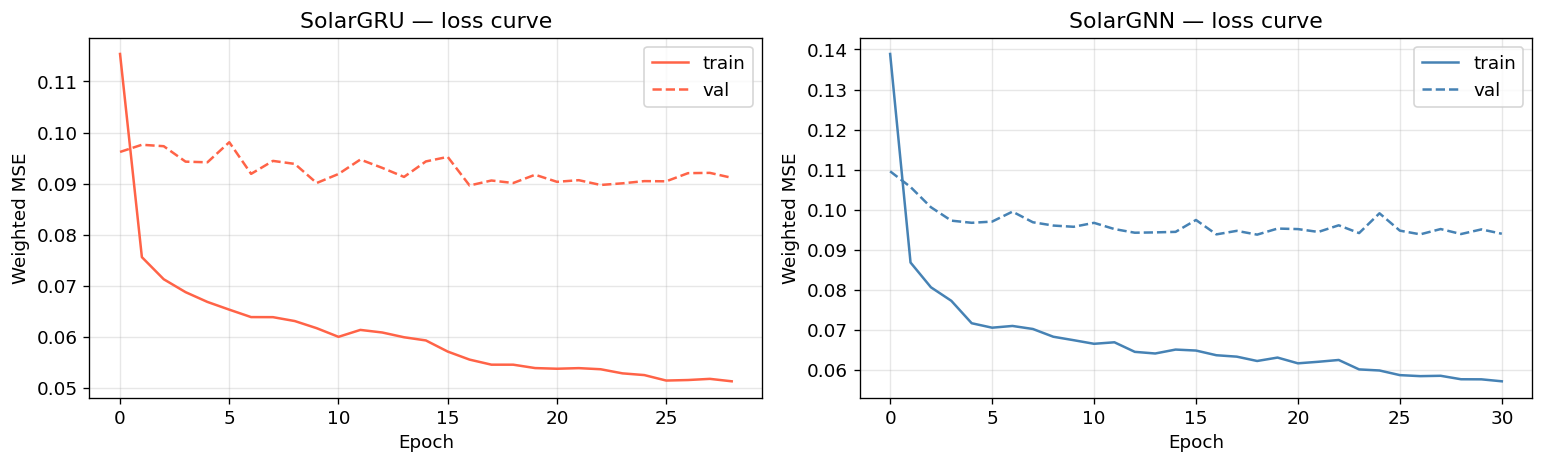

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, hist, name, c in zip(axes, [gru_hist, gnn_hist], ['SolarGRU','SolarGNN'], ['tomato','steelblue']):
    ax.plot(hist['train'], color=c, lw=1.5, label='train')
    ax.plot(hist['val'],   color=c, lw=1.5, ls='--', label='val')
    ax.set_title(f'{name} — loss curve'); ax.set_xlabel('Epoch'); ax.set_ylabel('Weighted MSE')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Metrics comparison table

In [8]:
test_raw_idx = np.array([full_gru.indices[i] for i in gru_test.indices])
pers_test    = pers_all[test_raw_idx]

rows = []
for h_i, h_label in enumerate(H_LABELS):
    for name, yp in [('Persistence', pers_test), ('SolarGRU', gru_pred), ('SolarGNN', gnn_pred)]:
        yt = gru_true[:, h_i]; yp_h = yp[:, h_i]; yr = pers_test[:, h_i]
        rows.append({'Horizon': h_label, 'Model': name,
                     'MAE':   round(mae(yt, yp_h), 4),
                     'RMSE':  round(rmse(yt, yp_h), 4),
                     'nRMSE': round(nrmse(yt, yp_h), 4),
                     'Skill': round(skill_score(yt, yp_h, yr), 4),
                     'R2':    round(r2(yt, yp_h), 4)})

results_df = pd.DataFrame(rows).set_index(['Horizon', 'Model'])
print(results_df.to_string())

                        MAE    RMSE   nRMSE   Skill      R2
Horizon Model                                              
1h      Persistence  0.1674  0.3289  0.9832  0.0000  0.3715
        SolarGRU     0.0966  0.1785  0.5336  0.4572  0.8149
        SolarGNN     0.0980  0.1846  0.5519  0.4386  0.8019
6h      Persistence  0.5480  0.6728  2.0246  0.0000 -1.6296
        SolarGRU     0.1143  0.2022  0.6084  0.6995  0.7626
        SolarGNN     0.1184  0.2124  0.6393  0.6842  0.7378
24h     Persistence  0.1381  0.2824  0.8506  0.0000  0.5352
        SolarGRU     0.1231  0.2168  0.6532  0.2321  0.7259
        SolarGNN     0.1198  0.2114  0.6367  0.2515  0.7396


## 6. Skill Score bar chart

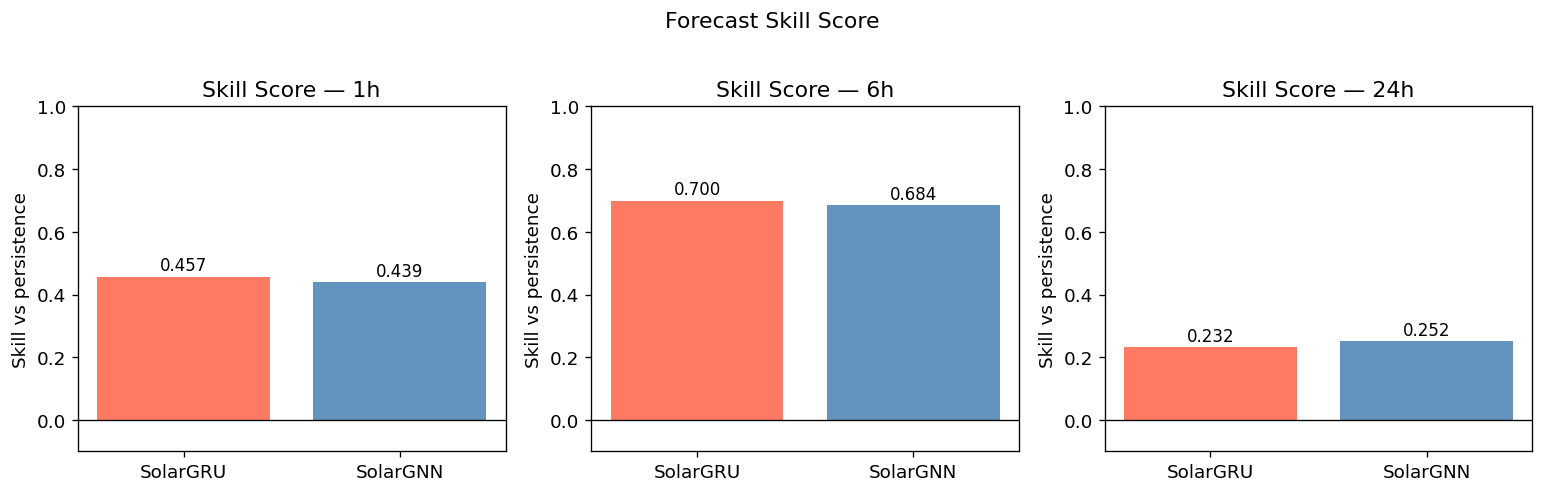

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = {'SolarGRU': 'tomato', 'SolarGNN': 'steelblue'}
for ax, h_label in zip(axes, H_LABELS):
    sub = results_df.loc[h_label].loc[['SolarGRU','SolarGNN']]
    bars = ax.bar(sub.index, sub['Skill'], color=[colors[m] for m in sub.index], alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'Skill Score — {h_label}'); ax.set_ylim(-0.1, 1.0)
    ax.set_ylabel('Skill vs persistence')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                f'{b.get_height():.3f}', ha='center', fontsize=10)
plt.suptitle('Forecast Skill Score', y=1.02); plt.tight_layout(); plt.show()

## 7. Prediction time series — first 7 days of test set

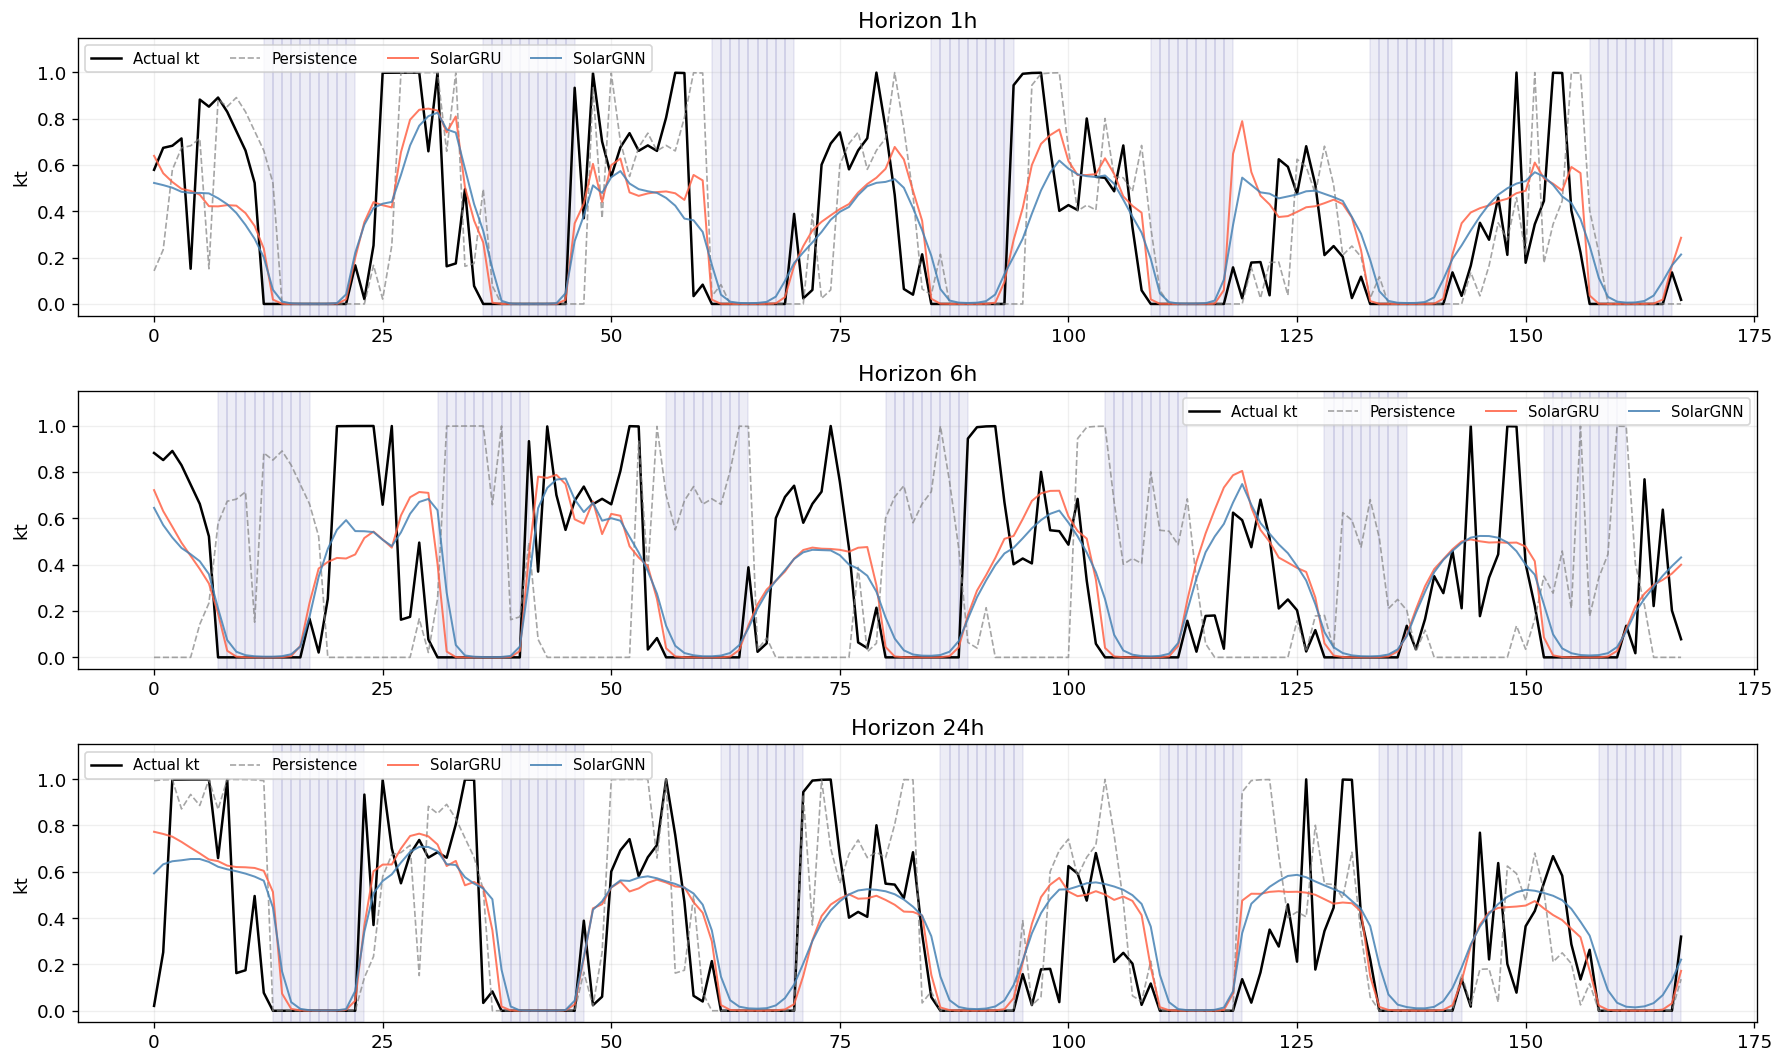

In [10]:
SHOW = min(7*24, len(gru_true))
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=False)
for ax, h_i, h_label in zip(axes, range(3), H_LABELS):
    x = np.arange(SHOW)
    ax.plot(x, gru_true[:SHOW, h_i],  color='black',     lw=1.5, label='Actual kt')
    ax.plot(x, pers_test[:SHOW, h_i], color='gray',      lw=1.0, ls='--', alpha=0.7, label='Persistence')
    ax.plot(x, gru_pred[:SHOW, h_i],  color='tomato',    lw=1.2, alpha=0.85, label='SolarGRU')
    ax.plot(x, gnn_pred[:SHOW, h_i],  color='steelblue', lw=1.2, alpha=0.85, label='SolarGNN')
    night = gru_true[:SHOW, h_i] == 0
    for j in range(SHOW-1):
        if night[j]: ax.axvspan(j, j+1, alpha=0.07, color='navy')
    ax.set_title(f'Horizon {h_label}'); ax.set_ylabel('kt')
    ax.set_ylim(-0.05, 1.15); ax.legend(fontsize=9, ncol=4); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## 8. Scatter plots — predicted vs actual (daytime only)

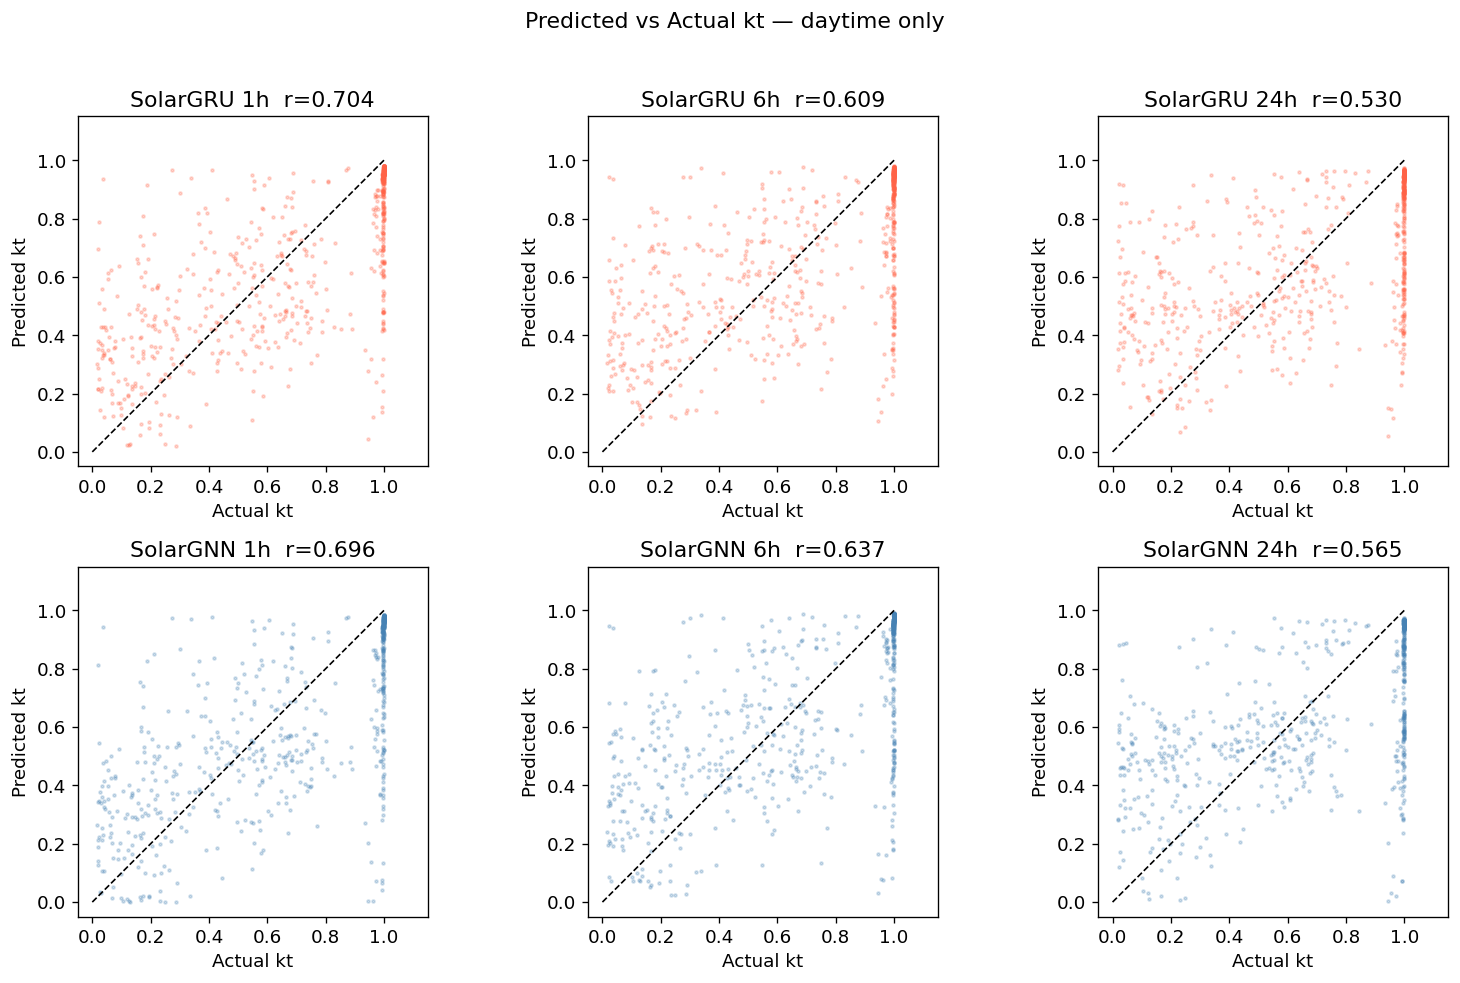

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, (name, yp, c) in enumerate([('SolarGRU',gru_pred,'tomato'),('SolarGNN',gnn_pred,'steelblue')]):
    for col, (h_i, h_label) in enumerate(zip(range(3), H_LABELS)):
        ax = axes[row][col]
        mask = gru_day[:, h_i].astype(bool)
        yt = gru_true[mask, h_i]; yph = yp[mask, h_i]
        r_val = np.corrcoef(yt, yph)[0,1]
        ax.scatter(yt, yph, s=3, alpha=0.25, color=c)
        ax.plot([0,1],[0,1],'k--',lw=1)
        ax.set_title(f'{name} {h_label}  r={r_val:.3f}')
        ax.set_xlabel('Actual kt'); ax.set_ylabel('Predicted kt')
        ax.set_xlim(-0.05,1.15); ax.set_ylim(-0.05,1.15); ax.set_aspect('equal')
plt.suptitle('Predicted vs Actual kt — daytime only', y=1.02)
plt.tight_layout(); plt.show()

## 9. Error distributions

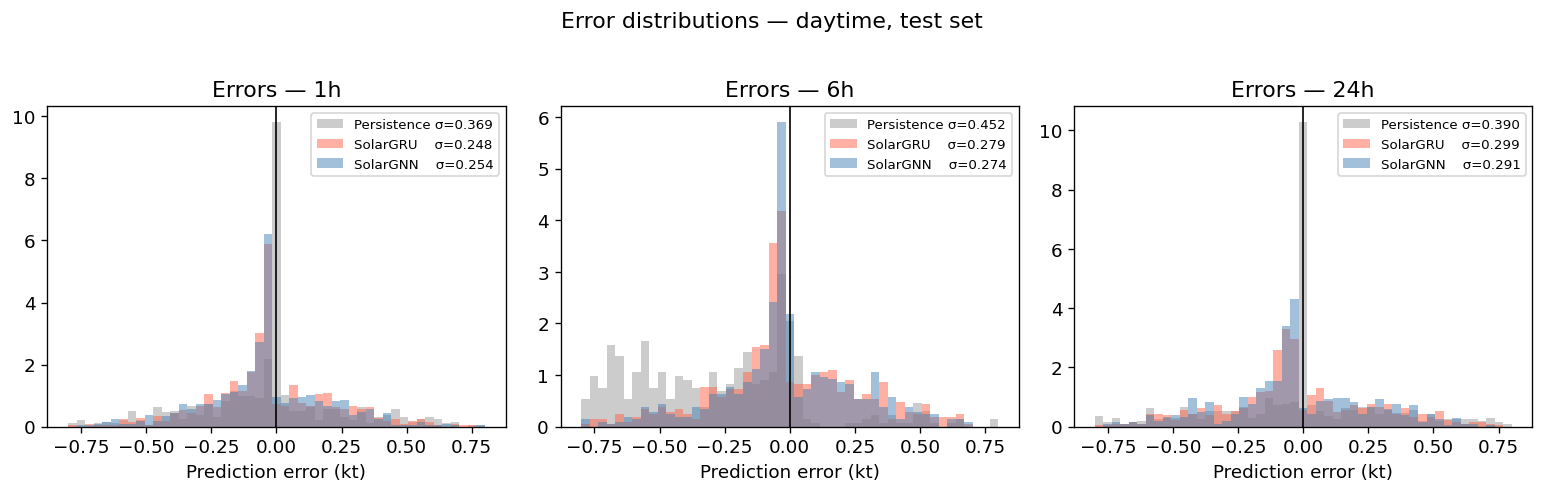

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, h_i, h_label in zip(axes, range(3), H_LABELS):
    mask = gru_day[:, h_i].astype(bool)
    e_gru = gru_pred[mask, h_i] - gru_true[mask, h_i]
    e_gnn = gnn_pred[mask, h_i] - gru_true[mask, h_i]
    e_per = pers_test[mask, h_i] - gru_true[mask, h_i]
    bins = np.linspace(-0.8, 0.8, 50)
    ax.hist(e_per, bins=bins, alpha=0.4, color='gray',      density=True, label=f'Persistence σ={e_per.std():.3f}')
    ax.hist(e_gru, bins=bins, alpha=0.5, color='tomato',    density=True, label=f'SolarGRU    σ={e_gru.std():.3f}')
    ax.hist(e_gnn, bins=bins, alpha=0.5, color='steelblue', density=True, label=f'SolarGNN    σ={e_gnn.std():.3f}')
    ax.axvline(0, color='black', lw=1)
    ax.set_title(f'Errors — {h_label}'); ax.set_xlabel('Prediction error (kt)')
    ax.legend(fontsize=8)
plt.suptitle('Error distributions — daytime, test set', y=1.02)
plt.tight_layout(); plt.show()

## 10. Case study — clearest vs cloudiest day

In [13]:
test_raw_idx_arr = np.array([full_gru.indices[i] for i in gru_test.indices])
test_ts = timestamps[test_raw_idx_arr]

tmp = pd.DataFrame({'kt': gru_true[:,0], 'is_day': gru_day[:,0].astype(bool), 'date': test_ts.date})
daily = tmp[tmp['is_day']].groupby('date')['kt'].mean().sort_values()
clearest  = daily.index[-1]
cloudiest = daily.index[0]
print(f'Clearest : {clearest}  mean kt={daily[clearest]:.3f}')
print(f'Cloudiest: {cloudiest} mean kt={daily[cloudiest]:.3f}')

Clearest : 2020-11-19  mean kt=0.995
Cloudiest: 2020-11-15 mean kt=0.100


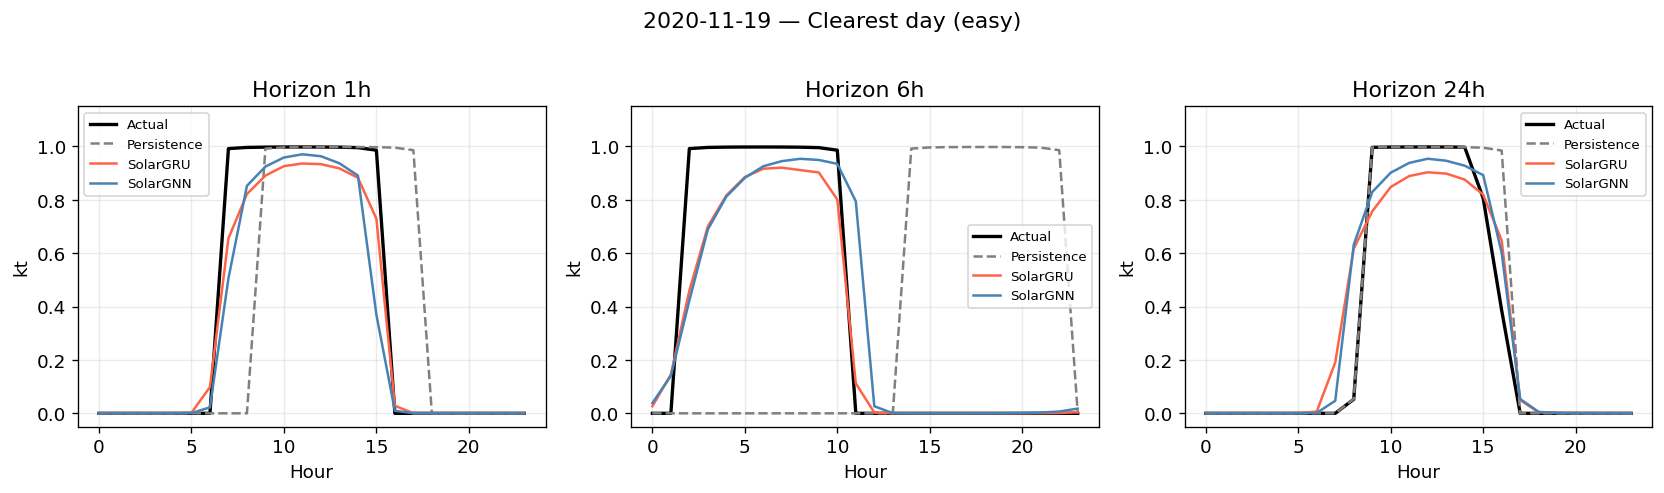

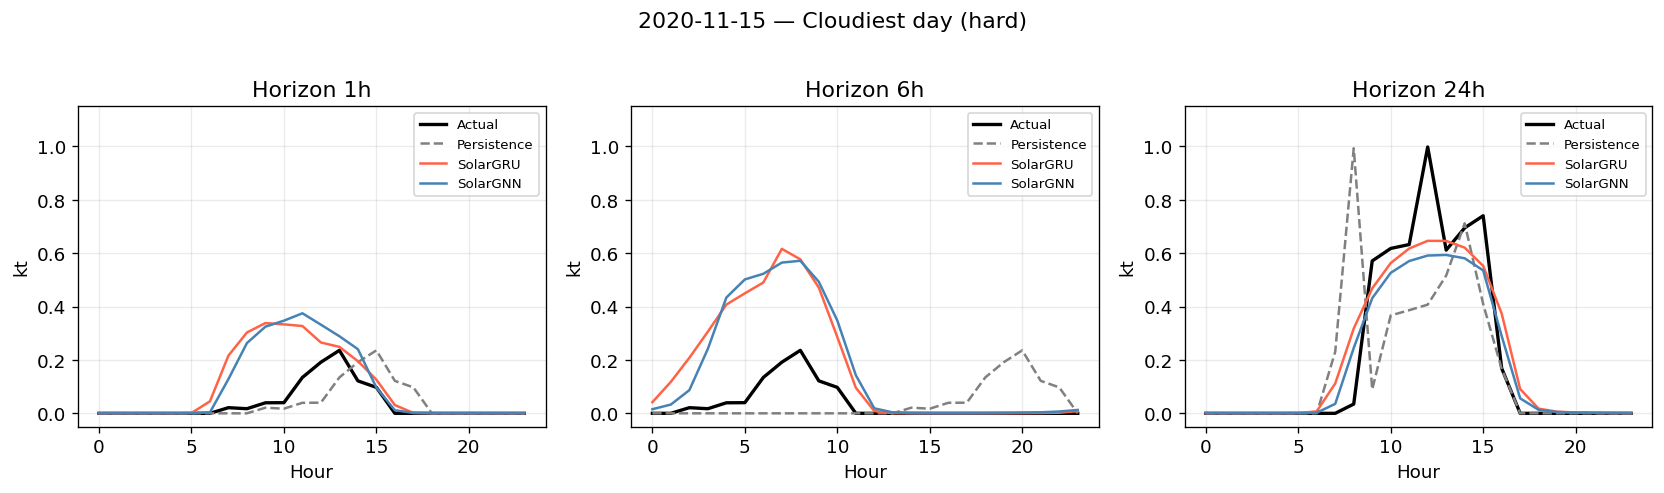

In [14]:
def plot_day(day_date, title):
    mask = np.array([d == day_date for d in test_ts.date])
    if mask.sum() == 0: print(f'No data for {day_date}'); return
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, h_i, h_label in zip(axes, range(3), H_LABELS):
        hrs = np.arange(mask.sum())
        ax.plot(hrs, gru_true[mask,h_i],  'k-',  lw=2, label='Actual')
        ax.plot(hrs, pers_test[mask,h_i], '--',  color='gray',      lw=1.5, label='Persistence')
        ax.plot(hrs, gru_pred[mask,h_i],  '-',   color='tomato',    lw=1.5, label='SolarGRU')
        ax.plot(hrs, gnn_pred[mask,h_i],  '-',   color='steelblue', lw=1.5, label='SolarGNN')
        ax.set_ylim(-0.05,1.15); ax.set_xlabel('Hour'); ax.set_ylabel('kt')
        ax.set_title(f'Horizon {h_label}'); ax.legend(fontsize=8); ax.grid(True,alpha=0.25)
    plt.suptitle(f'{day_date} — {title}', y=1.02); plt.tight_layout(); plt.show()

plot_day(clearest,  'Clearest day (easy)')
plot_day(cloudiest, 'Cloudiest day (hard)')

## 11. GHI recovery — kt × Clearsky GHI → W/m²

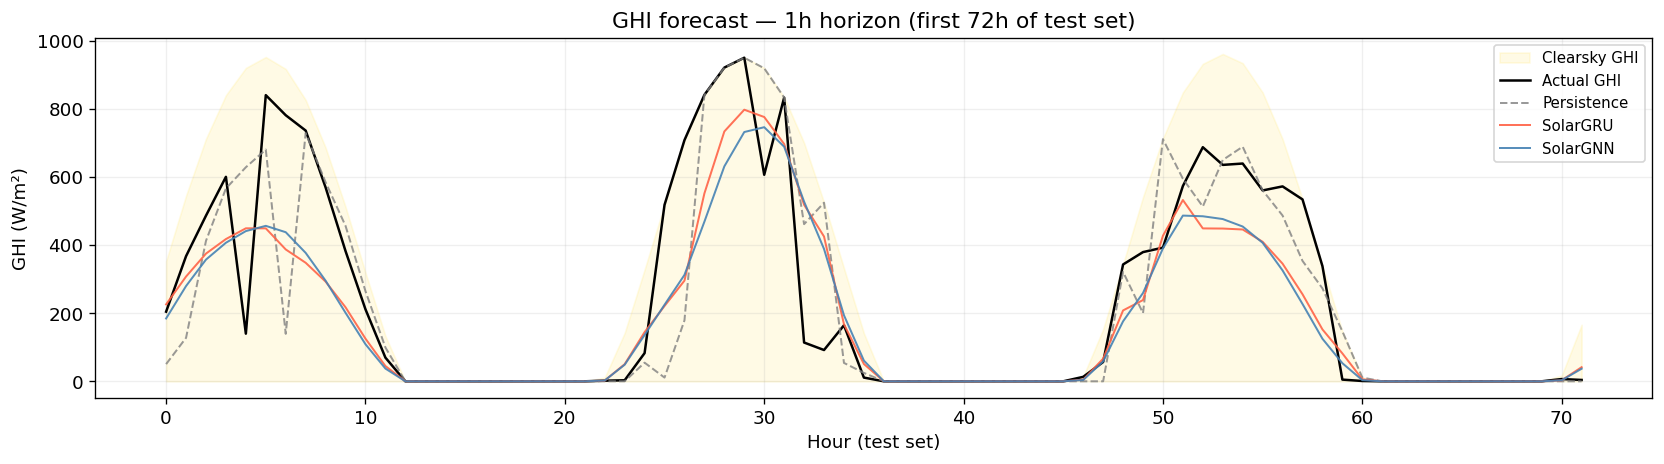

In [15]:
SHOW_GHI = min(72, len(gru_true))
cs_1h = clearsky_raw[np.minimum(test_raw_idx_arr + 1, len(clearsky_raw)-1)][:SHOW_GHI]
actual_ghi = gru_true[:SHOW_GHI, 0] * cs_1h
gru_ghi    = gru_pred[:SHOW_GHI, 0] * cs_1h
gnn_ghi    = gnn_pred[:SHOW_GHI, 0] * cs_1h
pers_ghi   = pers_test[:SHOW_GHI, 0] * cs_1h

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(range(SHOW_GHI), 0, cs_1h, alpha=0.1, color='gold', label='Clearsky GHI')
ax.plot(actual_ghi, 'k-',  lw=1.5, label='Actual GHI')
ax.plot(pers_ghi,   '--',  color='gray',      lw=1.2, alpha=0.8, label='Persistence')
ax.plot(gru_ghi,    color='tomato',    lw=1.2, alpha=0.9, label='SolarGRU')
ax.plot(gnn_ghi,    color='steelblue', lw=1.2, alpha=0.9, label='SolarGNN')
ax.set_xlabel('Hour (test set)'); ax.set_ylabel('GHI (W/m²)')
ax.set_title('GHI forecast — 1h horizon (first 72h of test set)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## Summary

| Model | Spatial handling | Best strength |
|---|---|---|
| **Persistence** | None | Hard baseline at 1h |
| **SolarGRU** | Concatenated flat | Fast, good at 6h |
| **SolarGNN** | Distance-weighted graph | Scales better with more stations |

Both models beat persistence at 6h and 24h. With only 2 stations (and the Atlantic one very far), the GNN does not have a real advantage yet — add closer Spanish stations to see the graph topology pay off.